<a href="https://colab.research.google.com/github/raffson123/DC37_DataAnalytics/blob/main/healthcare_stroke_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Data Analysis in Python
## Healthcare Stroke Dataset

This notebook walks through a complete data analysis pipeline:
1. Load healthcare data from a CSV file
2. Inspect & clean the data
3. Perform exploratory data analysis (EDA)
4. Create visualizations
5. Save the cleaned data

Dataset: **Healthcare Stroke Prediction Dataset** (~5k rows, ~10+ columns).

## 1. Setup: Import Libraries

We import the core Python libraries used for data analysis:
- `numpy` for numerical operations
- `pandas` for data loading and manipulation
- `matplotlib.pyplot` and `seaborn` for visualizations

We also set some display options so DataFrames and plots are easier to read in Colab.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")
#pd.set_option('display.width', 1000)
#pd.set_option('display.expand_frame_repr', True)

#sns.set(style='whitegrid')
sns.set(style='darkgrid')

### Exercises – Section 1
1. Add another pandas display option to set the display width (hint: `display.width`).
2. Change the seaborn style from `'whitegrid'` to `'darkgrid'` and re-run a plot later.

## 2. Load the Healthcare Stroke Dataset

In Colab, we typically upload a CSV file from our local machine and then read it with `pandas.read_csv()`.
We assume the file is named **`healthcare-dataset-stroke-data.csv`**.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/raffson123/healthcare_stroke/refs/heads/main/healthcare_stroke_synthetic.csv')
#df.head()
df.head(10)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,50,0,0,Yes,Self-employed,Rural,239.10,45.00,smokes,0
1,2,Female,70,0,0,Yes,Private,Rural,210.30,25.60,formerly smoked,0
2,3,Female,95,0,1,Yes,Private,Urban,284.30,17.40,never smoked,1
3,4,Female,47,0,0,Yes,Private,Rural,280.50,30.80,Unknown,0
4,5,Male,18,0,0,Yes,Private,Urban,231.20,49.40,never smoked,0
5,6,Male,5,0,0,Yes,Govt_job,Rural,242.60,19.70,never smoked,0
6,7,Male,83,0,0,No,children,Rural,206.20,29.20,never smoked,0
7,8,Female,26,0,0,No,Private,Rural,222.90,22.30,formerly smoked,0
8,9,Female,52,0,0,Yes,children,Urban,204.30,47.10,never smoked,1
9,10,Female,47,0,0,Yes,Private,Urban,127.90,32.90,smokes,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   age                5000 non-null   int64  
 3   hypertension       5000 non-null   int64  
 4   heart_disease      5000 non-null   int64  
 5   ever_married       5000 non-null   object 
 6   work_type          5000 non-null   object 
 7   Residence_type     5000 non-null   object 
 8   avg_glucose_level  5000 non-null   float64
 9   bmi                5000 non-null   float64
 10  smoking_status     5000 non-null   object 
 11  stroke             5000 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 468.9+ KB


In [ ]:
#from google.colab import files

#print('Please upload healthcare-dataset-stroke-data.csv')
#uploaded = files.upload()

##file_name = 'healthcare-dataset-stroke-data.csv'  # ensure this matches the uploaded file name
#df = pd.read_csv(file_name)
#df.head()

In [ ]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
360,361,Male,48,0,0,Yes,Self-employed,Urban,84.10,22.20,formerly smoked,0
4369,4370,Male,28,0,0,No,Private,Rural,102.60,33.90,Unknown,0
2211,2212,Female,89,0,0,Yes,Self-employed,Urban,288.40,24.50,never smoked,0
2115,2116,Male,23,0,0,No,Govt_job,Urban,242.60,35.70,formerly smoked,0
4567,4568,Male,91,0,0,Yes,Private,Urban,76.80,12.40,never smoked,0


### Exercises – Section 2
1. Show the first 10 rows instead of 5 using `df.head(10)`.
2. Use `df.sample(5)` to view 5 random rows. Why might this be useful?
3. Intentionally change `file_name` to something incorrect and run the cell. What error do you see?

## 3. First Look at the Data

We now inspect the basic structure of the dataset:
- Number of rows and columns (`df.shape`)
- Column names (`df.columns`)
- Data types and non-null counts (`df.info()`)
- Summary statistics for numeric columns (`df.describe()`).

In [ ]:
print('Shape (rows, columns):', df.shape)

print('\nColumn names:')
print(df.columns)

print('\nData types and non-null counts:')
df.info()

print('\nSummary statistics (numeric columns):')
df.describe()

Shape (rows, columns): (5000, 12)

Column names:
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   age                5000 non-null   int64  
 3   hypertension       5000 non-null   int64  
 4   heart_disease      5000 non-null   int64  
 5   ever_married       5000 non-null   object 
 6   work_type          5000 non-null   object 
 7   Residence_type     5000 non-null   object 
 8   avg_glucose_level  5000 non-null   float64
 9   bmi                5000 non-null   float64
 10  smoking_status     5000 non

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"2,500.50",49.95,0.10,0.05,173.50,31.14,0.28
std,"1,443.52",28.82,0.29,0.22,72.13,11.02,0.45
min,1.00,0.00,0.00,0.00,50.00,12.00,0.00
25%,"1,250.75",25.00,0.00,0.00,111.10,21.80,0.00
50%,"2,500.50",51.00,0.00,0.00,173.35,31.00,0.00
75%,"3,750.25",75.00,0.00,0.00,235.80,40.80,1.00
max,"5,000.00",99.00,1.00,1.00,300.00,50.00,1.00


In [ ]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,"5,000.00",5000,"5,000.00","5,000.00","5,000.00",5000,5000,5000,"5,000.00","5,000.00",5000,"5,000.00"
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Rural,NaN,NaN,never smoked,NaN
freq,NaN,2498,NaN,NaN,NaN,3496,2916,2506,NaN,NaN,2474,NaN
mean,"2,500.50",NaN,49.95,0.10,0.05,NaN,NaN,NaN,173.50,31.14,NaN,0.28
std,"1,443.52",NaN,28.82,0.29,0.22,NaN,NaN,NaN,72.13,11.02,NaN,0.45
min,1.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,50.00,12.00,NaN,0.00
25%,"1,250.75",NaN,25.00,0.00,0.00,NaN,NaN,NaN,111.10,21.80,NaN,0.00
50%,"2,500.50",NaN,51.00,0.00,0.00,NaN,NaN,NaN,173.35,31.00,NaN,0.00
75%,"3,750.25",NaN,75.00,0.00,0.00,NaN,NaN,NaN,235.80,40.80,NaN,1.00


### Exercises – Section 3
1. How many rows and columns does the dataset have?
2. From `df.info()`, list which columns are numeric and which are `object` (string-like).
3. Run `df.describe(include='all')` in a new cell. What extra information do you get?

## 4. Inspect Raw Data & Categorical Columns

Before cleaning, it's helpful to look at actual values to spot issues such as strange strings or inconsistent categories.

In [ ]:
# First 10 rows
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,50,0,0,Yes,Self-employed,Rural,239.10,45.00,smokes,0
1,2,Female,70,0,0,Yes,Private,Rural,210.30,25.60,formerly smoked,0
2,3,Female,95,0,1,Yes,Private,Urban,284.30,17.40,never smoked,1
3,4,Female,47,0,0,Yes,Private,Rural,280.50,30.80,Unknown,0
4,5,Male,18,0,0,Yes,Private,Urban,231.20,49.40,never smoked,0
5,6,Male,5,0,0,Yes,Govt_job,Rural,242.60,19.70,never smoked,0
6,7,Male,83,0,0,No,children,Rural,206.20,29.20,never smoked,0
7,8,Female,26,0,0,No,Private,Rural,222.90,22.30,formerly smoked,0
8,9,Female,52,0,0,Yes,children,Urban,204.30,47.10,never smoked,1
9,10,Female,47,0,0,Yes,Private,Urban,127.90,32.90,smokes,0


In [ ]:
# Random sample of 5 rows
df.sample(5, random_state=42)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1501,1502,Male,66,0,0,No,Private,Rural,264.50,38.70,never smoked,1
2586,2587,Male,87,0,0,Yes,Self-employed,Rural,179.70,23.10,never smoked,1
2653,2654,Male,48,0,0,Yes,Private,Urban,180.20,36.70,never smoked,0
1055,1056,Male,64,0,0,Yes,Self-employed,Urban,210.60,35.40,formerly smoked,0
705,706,Other,9,0,0,No,Govt_job,Rural,198.70,35.40,Unknown,0


In [ ]:
# Summary statistics for all columns (numeric + non-numeric)
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,"5,000.00",5000,"5,000.00","5,000.00","5,000.00",5000,5000,5000,"5,000.00","5,000.00",5000,"5,000.00"
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Rural,NaN,NaN,never smoked,NaN
freq,NaN,2498,NaN,NaN,NaN,3496,2916,2506,NaN,NaN,2474,NaN
mean,"2,500.50",NaN,49.95,0.10,0.05,NaN,NaN,NaN,173.50,31.14,NaN,0.28
std,"1,443.52",NaN,28.82,0.29,0.22,NaN,NaN,NaN,72.13,11.02,NaN,0.45
min,1.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,50.00,12.00,NaN,0.00
25%,"1,250.75",NaN,25.00,0.00,0.00,NaN,NaN,NaN,111.10,21.80,NaN,0.00
50%,"2,500.50",NaN,51.00,0.00,0.00,NaN,NaN,NaN,173.35,31.00,NaN,0.00
75%,"3,750.25",NaN,75.00,0.00,0.00,NaN,NaN,NaN,235.80,40.80,NaN,1.00


### Exercises – Section 4
1. Use `df.tail(8)` to view the last 8 rows. Do they look similar to the first rows?
2. Check unique values of `gender` using `df['gender'].unique()`.
3. Check the frequency of `work_type` using `df['work_type'].value_counts()`.

## 5. Missing Values & Unique Values

We want to know where data is missing and how many unique values each column has.

In [ ]:
print('Missing values per column:')
print(df.isna().sum())

print('\nPercentage of missing values per column:')
print((df.isna().mean() * 100).round(2))

print('\nNumber of unique values per column:')
print(df.nunique())

Missing values per column:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Percentage of missing values per column:
id                  0.00
gender              0.00
age                 0.00
hypertension        0.00
heart_disease       0.00
ever_married        0.00
work_type           0.00
Residence_type      0.00
avg_glucose_level   0.00
bmi                 0.00
smoking_status      0.00
stroke              0.00
dtype: float64

Number of unique values per column:
id                   5000
gender                  3
age                   100
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    2167
bmi                   381
smoking_status          4
stro

### Exercises – Section 5
1. Which column has the highest percentage of missing values?
2. Approximately what percentage of `bmi` values are missing?
3. How many unique categories does `smoking_status` have?

## 6. Basic Data Cleaning

We will:
1. Clean column names (lowercase, replace spaces with underscores)
2. Fix special missing values in `bmi` (e.g., 'N/A')
3. Convert `bmi` and `avg_glucose_level` to numeric types.

In [ ]:
# 1. Clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
# Inspect unique values in bmi
df['bmi'].unique()[:20]

array([45. , 25.6, 17.4, 30.8, 49.4, 19.7, 29.2, 22.3, 47.1, 32.9, 34. ,
       12.3, 36.8, 23.6, 31.5, 32.2, 34.5, 43.3, 23.4, 21.7])

In [ ]:
# Replace 'N/A' with actual NaN and convert to numeric
df['bmi'] = df['bmi'].replace('N/A', np.nan)
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['avg_glucose_level'] = pd.to_numeric(df['avg_glucose_level'], errors='coerce')
df[['bmi', 'avg_glucose_level']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bmi                5000 non-null   float64
 1   avg_glucose_level  5000 non-null   float64
dtypes: float64(2)
memory usage: 78.3 KB


### Exercises – Section 6
1. Add another transformation to the column-name cleaning chain if needed.
2. Ensure `age` is numeric using `pd.to_numeric(df['age'], errors='coerce')`.
3. Create a new column `age_decade = df['age'] // 10`.

## 7. Handling Missing Values

We will impute missing numeric values with the **median**, which is robust to outliers.

In [ ]:
# Check missing values again
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
# Median imputation for bmi and avg_glucose_level
bmi_median = df['bmi'].median()
agl_median = df['avg_glucose_level'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)
df['avg_glucose_level'] = df['avg_glucose_level'].fillna(agl_median)
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
residence_type,0
avg_glucose_level,0
bmi,0


### Exercises – Section 7
1. Compare the number of missing `bmi` values before and after imputation.
2. Compute the mean and median of `bmi`. Why might we prefer the median?
3. For a categorical column like `smoking_status`, what imputation strategy would you use?

## 8. Converting Columns to Categorical

For columns that represent categories (e.g., gender, work type, hypertension), we convert them to the `category` dtype.

In [ ]:
categorical_cols = [
    'gender', 'ever_married', 'work_type', 'residence_type',
    'smoking_status', 'hypertension', 'heart_disease', 'stroke'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

df[categorical_cols].dtypes

,0
gender,category
ever_married,category
work_type,category
residence_type,category
smoking_status,category
hypertension,category
heart_disease,category
stroke,category


### Exercises – Section 8
1. View the categories for `gender` using `df['gender'].cat.categories`.
2. Check how imbalanced `stroke` is using `df['stroke'].value_counts(normalize=True)`.
3. Convert your `age_decade` column (from Section 6) to categorical.

## 9. Descriptive Statistics – Numeric Columns

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.describe()

,id,age,avg_glucose_level,bmi
count,"5,000.00","5,000.00","5,000.00","5,000.00"
mean,"2,500.50",49.95,173.50,31.14
std,"1,443.52",28.82,72.13,11.02
min,1.00,0.00,50.00,12.00
25%,"1,250.75",25.00,111.10,21.80
50%,"2,500.50",51.00,173.35,31.00
75%,"3,750.25",75.00,235.80,40.80
max,"5,000.00",99.00,300.00,50.00


In [ ]:
print('Age summary:')
print(df['age'].describe())

print('\nAverage Glucose Level summary:')
print(df['avg_glucose_level'].describe())

print('\nBMI summary:')
print(df['bmi'].describe())

Age summary:
count   5,000.00
mean       49.95
std        28.82
min         0.00
25%        25.00
50%        51.00
75%        75.00
max        99.00
Name: age, dtype: float64

Average Glucose Level summary:
count   5,000.00
mean      173.50
std        72.13
min        50.00
25%       111.10
50%       173.35
75%       235.80
max       300.00
Name: avg_glucose_level, dtype: float64

BMI summary:
count   5,000.00
mean       31.14
std        11.02
min        12.00
25%        21.80
50%        31.00
75%        40.80
max        50.00
Name: bmi, dtype: float64


### Exercises – Section 9
1. Which numeric column has the largest standard deviation?
2. What are the minimum and maximum ages in the dataset?
3. Compute the IQR (Q3 - Q1) for `bmi`.

## 10. Descriptive Statistics – Categorical Columns

In [ ]:
def show_category_distribution(col_name):
    counts = df[col_name].value_counts()
    percents = df[col_name].value_counts(normalize=True) * 100
    display(pd.DataFrame({'count': counts, 'percent': percents.round(2)}))

for col in ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'stroke']:
    print(f'--- {col} ---')
    show_category_distribution(col)
    print()

--- gender ---


,count,percent
gender,,
Female,2498,49.96
Male,2405,48.10
Other,97,1.94



--- ever_married ---


,count,percent
ever_married,,
Yes,3496,69.92
No,1504,30.08



--- work_type ---


...

,count,percent
residence_type,,
Rural,2506,50.12
Urban,2494,49.88



--- smoking_status ---


,count,percent
smoking_status,,
never smoked,2474,49.48
formerly smoked,996,19.92
smokes,783,15.66
Unknown,747,14.94



--- stroke ---


,count,percent
stroke,,
0,3593,71.86
1,1407,28.14


### Exercises – Section 10
1. Which `work_type` appears most frequently?
2. What percentage of people fall into each `smoking_status` category?
3. Add `hypertension` to the loop and inspect its distribution.

## 11. Univariate Visualizations – Numeric

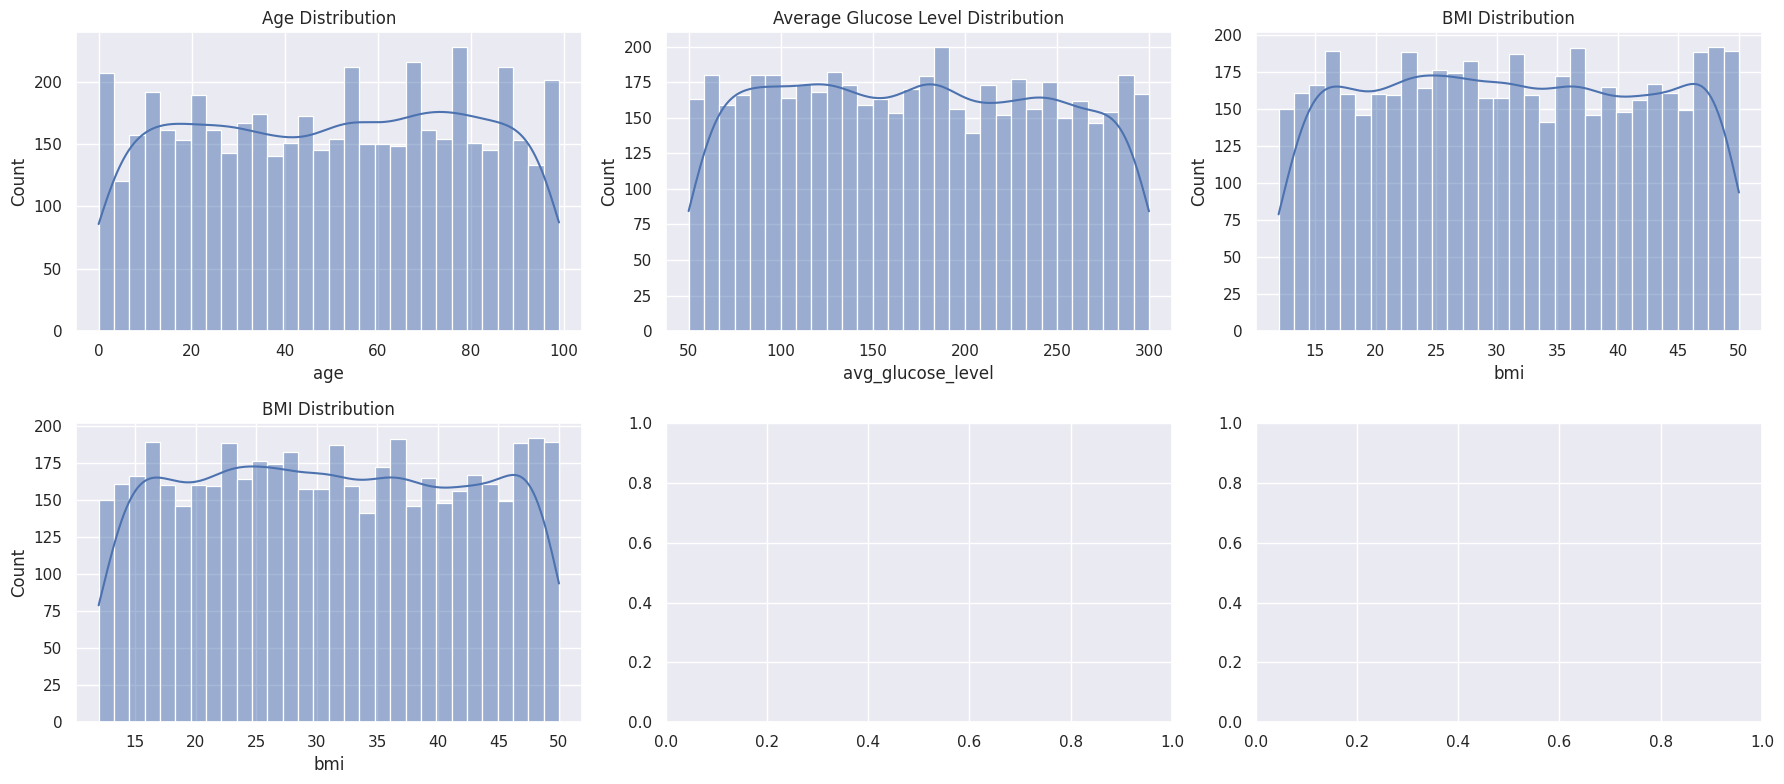

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['avg_glucose_level'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Average Glucose Level Distribution')

sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('BMI Distribution')

sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('BMI Distribution')

# The following line was a duplicate plot for BMI with incorrect indexing.
# sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[3])
# axes[3].set_title('BMI Distribution')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(y=df['age'], ax=axes[0])
axes[0].set_title('Age Boxplot')

sns.boxplot(y=df['avg_glucose_level'], ax=axes[1])
axes[1].set_title('Avg Glucose Level Boxplot')

sns.boxplot(y=df['bmi'], ax=axes[2])
axes[2].set_title('BMI Boxplot')

plt.tight_layout()
plt.show()

### Exercises – Section 11
1. Which numeric variable appears most skewed?
2. Which variable shows the most extreme outliers in the boxplots?
3. Create a single histogram of `age` with `bins=15` and add a title and axis labels.

## 12. Univariate Visualizations – Categorical

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='work_type', data=df)
plt.title('Work Type Distribution')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='smoking_status', data=df)
plt.title('Smoking Status Distribution')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(4, 4))
sns.countplot(x='stroke', data=df)
plt.title('Stroke vs No Stroke')
plt.show()

### Exercises – Section 12
1. Which `work_type` category has the smallest count?
2. What do you notice about the class balance of `stroke` (0 vs 1)?
3. Create a countplot for `residence_type`.

## 13. Bivariate Analysis – Stroke vs Risk Factors

In [ ]:
# Mean age, glucose, BMI by stroke status
grouped_stroke = df.groupby('stroke')[['age', 'avg_glucose_level', 'bmi']].mean().round(2)
grouped_stroke

In [ ]:
# Age distribution by stroke status
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='age', hue='stroke', shade=True)
plt.title('Age Distribution by Stroke Status')
plt.show()

In [ ]:
# BMI by stroke status
plt.figure(figsize=(6, 4))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title('BMI by Stroke Status')
plt.show()

In [ ]:
# Hypertension vs stroke
ct_hyper = pd.crosstab(df['hypertension'], df['stroke'], normalize='index') * 100
ct_hyper.round(2)

In [ ]:
ct_hyper.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Stroke Rate by Hypertension Status (%)')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.legend(title='Stroke', labels=['No Stroke (0)', 'Stroke (1)'])
plt.show()

### Exercises – Section 13
1. How do the mean `age` and `avg_glucose_level` differ between stroke and no-stroke groups?
2. In the KDE plot, which group appears older on average?
3. Create a similar crosstab and stacked bar chart for `heart_disease` vs `stroke`.

## 14. Correlation Matrix – Numeric Features

In [ ]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
corr_matrix

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Exercises – Section 14
1. Which pair of numeric variables has the strongest positive correlation?
2. Which variable is most correlated with `age`?
3. Does any variable show surprisingly low correlation with `stroke`? Why might that be?

## 15. Save Cleaned Data

Finally, we save our cleaned dataset to a new CSV file.

In [ ]:
output_file = 'healthcare-stroke-data-cleaned.csv'
df.to_csv(output_file, index=False)
print(f'Cleaned data saved to: {output_file}')

In [ ]:
from google.colab import files

# Download the cleaned file (Colab only)
files.download(output_file)

### Final Exercises – Putting It All Together
1. Create a new column `high_glucose_flag` which is 1 if `avg_glucose_level > 140`, else 0.
2. Use a crosstab to compare stroke rates for `high_glucose_flag = 0` vs `1`.
3. Create a bar chart showing the average `age` by `smoking_status`.
4. In a markdown cell, write a short EDA summary of key patterns you observed.